In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
import umap
import joblib
import json
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Load the preprocessed data from Part 2
# We'll load raw data and re-apply preprocessing to keep it self-contained
df = pd.read_csv('../data/city_lifestyle_dataset.csv')

# --- Preprocessing (same as Part 2) ---
# One-hot encode country
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)

# Drop city_name (identifier)
X = df_encoded.drop(['city_name'], axis=1)

# Define your 8 numeric features (EXACT column names)
feature_cols = [
    'population_density',
    'avg_income',
    'internet_penetration',
    'avg_rent',
    'air_quality_index',
    'public_transport_score',
    'happiness_score',
    'green_space_ratio'
]

# Add any one-hot encoded country columns to feature_cols
# (they start with 'country_' after get_dummies)
country_dummies = [col for col in X.columns if col.startswith('country_')]
feature_cols = feature_cols + country_dummies

print(f"Total features used for clustering: {len(feature_cols)}")
print(feature_cols)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

c:\Users\USER\Desktop\NaKuanRen_BIT_B2201F-2505003_clustering_app\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total features used for clustering: 13
['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio', 'country_Asia', 'country_Europe', 'country_North America', 'country_Oceania', 'country_South America']


In [3]:
# Grid search for optimal HDBSCAN parameters
best_score = -1
best_params = {}
best_labels = None

min_cluster_sizes = [5, 10, 15, 20]
min_samples_list = [3, 5, 7, 10]

print("Tuning HDBSCAN hyperparameters...")
for min_size in min_cluster_sizes:
    for min_samp in min_samples_list:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size,
            min_samples=min_samp,
            metric='euclidean',
            cluster_selection_method='eom',
            gen_min_span_tree=True
        )
        labels = clusterer.fit_predict(X_scaled)
        
        # Only evaluate if we have at least 2 clusters AND some non-noise points
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        if n_clusters >= 2 and len(labels[labels != -1]) > 0:
            try:
                # Filter out noise for silhouette score
                mask = labels != -1
                if mask.sum() > 1 and len(set(labels[mask])) >= 2:
                    score = silhouette_score(X_scaled[mask], labels[mask])
                    if score > best_score:
                        best_score = score
                        best_params = {
                            'min_cluster_size': min_size,
                            'min_samples': min_samp
                        }
                        best_labels = labels
            except:
                continue

print(f"\n✅ Best parameters: {best_params}")
print(f"✅ Best silhouette score: {best_score:.3f}")

Tuning HDBSCAN hyperparameters...

✅ Best parameters: {'min_cluster_size': 5, 'min_samples': 10}
✅ Best silhouette score: 0.461


In [3]:
# Train final model with best parameters
final_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=best_params['min_cluster_size'],
    min_samples=best_params['min_samples'],
    metric='euclidean',
    cluster_selection_method='eom',
    gen_min_span_tree=True,
    prediction_data=True  # IMPORTANT: enables predict() for new data
)

labels = final_clusterer.fit_predict(X_scaled)

# Stats
n_clusters = len(set(labels) - {-1})
n_noise = list(labels).count(-1)
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Cluster labels: {set(labels)}")

Number of clusters found: 6
Number of noise points: 7
Cluster labels: {0, 1, 2, 3, 4, 5, -1}


c:\Users\USER\Desktop\NaKuanRen_BIT_B2201F-2505003_clustering_app\venv\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


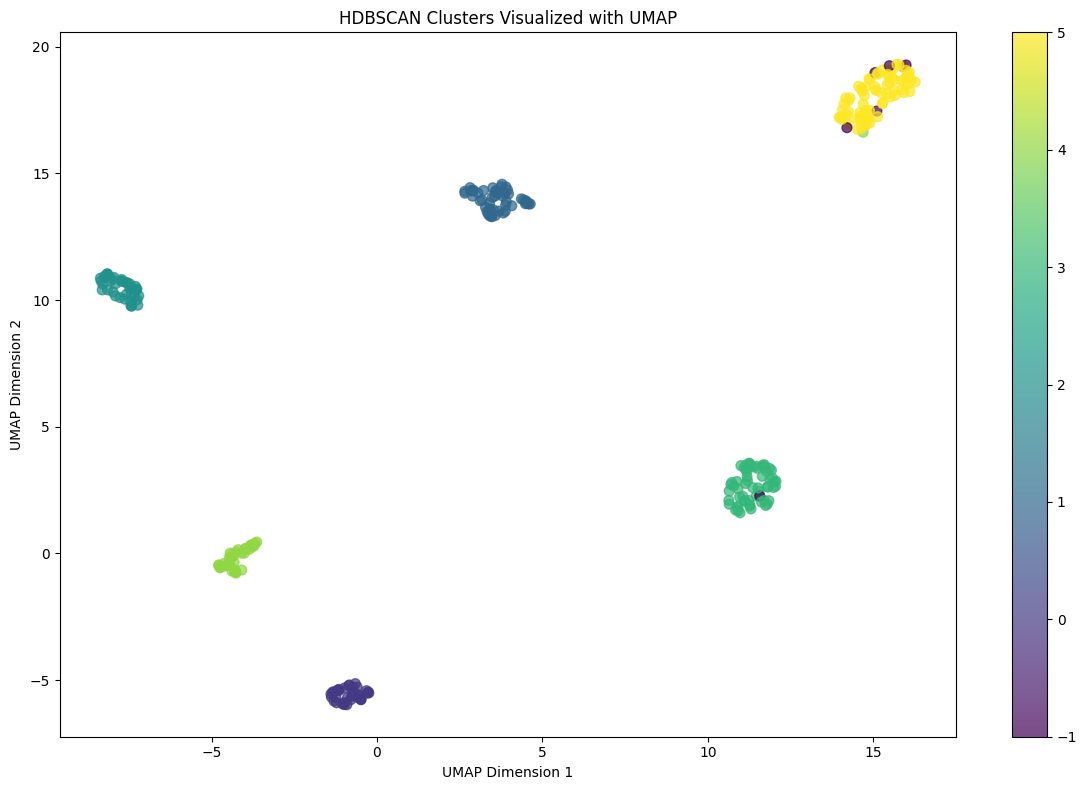

In [4]:
# UMAP for 2D projection (NOT PCA!)
reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)
X_umap = reducer.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter)
plt.title('HDBSCAN Clusters Visualized with UMAP')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.tight_layout()
plt.savefig('../cluster_visualization.png')
plt.show()

In [5]:
from sklearn.pipeline import Pipeline

# Create a full pipeline: scaler + clusterer
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clusterer', final_clusterer)
])

# Fit the pipeline on the full dataset
pipeline.fit(X[feature_cols])

# Save all components
joblib.dump(pipeline, '../models/clustering_pipeline.pkl')
joblib.dump(reducer, '../models/umap_reducer.pkl')

# Save feature names (CRITICAL for the app)
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_cols, f)

# Also save the original data for cluster profiling in Part 4
df.to_csv('../data/df_with_clusters.csv', index=False)

print("✅ All models saved successfully to /models folder!")

✅ All models saved successfully to /models folder!


In [6]:
# Use the labels from final model
mask = labels != -1
if mask.sum() > 1 and len(set(labels[mask])) >= 2:
    sil_score = silhouette_score(X_scaled[mask], labels[mask])
    db_score = davies_bouldin_score(X_scaled[mask], labels[mask])
    ch_score = calinski_harabasz_score(X_scaled[mask], labels[mask])
    
    print(f"✅ Silhouette Score: {sil_score:.3f} (higher = better, range -1 to 1)")
    print(f"✅ Davies-Bouldin Index: {db_score:.3f} (lower = better)")
    print(f"✅ Calinski-Harabasz Index: {ch_score:.3f} (higher = better)")
else:
    print("⚠️ Not enough clusters for valid metrics.")

✅ Silhouette Score: 0.461 (higher = better, range -1 to 1)
✅ Davies-Bouldin Index: 0.844 (lower = better)
✅ Calinski-Harabasz Index: 170.197 (higher = better)


In [8]:
# Define ONLY the 8 numeric features (exclude country dummies)
numeric_features = [
    'population_density',
    'avg_income',
    'internet_penetration',
    'avg_rent',
    'air_quality_index',
    'public_transport_score',
    'happiness_score',
    'green_space_ratio'
]

# Add cluster labels to original dataframe
df['cluster'] = labels

# Profile each cluster using numeric features only
cluster_profiles = df.groupby('cluster')[numeric_features].mean()
print("📊 Cluster Profiles (mean values):")
print(cluster_profiles.round(2))

# Count cities per cluster
cluster_counts = df['cluster'].value_counts().sort_index()
print("\n📈 Cities per cluster:")
print(cluster_counts)

# --- Bonus: Country distribution per cluster ---
# This gives a nice interpretation of geographic spread
country_dist = df.groupby('cluster')['country'].value_counts().unstack(fill_value=0)
print("\n🌍 Country distribution per cluster:")
print(country_dist)

📊 Cluster Profiles (mean values):
         population_density  avg_income  internet_penetration  avg_rent  \
cluster                                                                   
-1                  8247.00     2498.57                 70.34    964.29   
 0                  1162.80     3751.71                 87.41   1304.00   
 1                  2459.52     4176.40                 88.52   1479.20   
 2                  4037.38     1821.50                 62.36    643.75   
 3                  3048.49     3435.76                 83.18   1250.51   
 4                  2133.22      882.22                 44.75    301.94   
 5                  7450.66     2509.73                 72.62    877.81   

         air_quality_index  public_transport_score  happiness_score  \
cluster                                                               
-1                   86.57                   72.27             5.57   
 0                   38.80                   56.58             8.40   
 1    

In [10]:
# --- Cell 7: Cluster Profiling and Unique Naming (COMPLETE VERSION) ---

# 1. Check if 'labels' exists. If not, tell the user to run Cell 3 first.
try:
    labels
except NameError:
    print("❌ ERROR: 'labels' not found. Please run the HDBSCAN fitting cell (Cell 3) first.")
    raise

# 2. Add cluster labels back to the dataframe (if not already done)
df['cluster'] = labels

# 3. Define your numeric features (must match your dataset exactly)
numeric_features = [
    'population_density',
    'avg_income',
    'internet_penetration',
    'avg_rent',
    'air_quality_index',
    'public_transport_score',
    'happiness_score',
    'green_space_ratio'
]

# 4. Re-create the cluster profiles and counts (so they exist in this cell)
cluster_profiles = df.groupby('cluster')[numeric_features].mean()
cluster_counts = df['cluster'].value_counts().sort_index()

print("📊 Cluster Profiles (mean values):")
print(cluster_profiles.round(2))
print("\n📈 Cities per cluster:")
print(cluster_counts)

# 5. --- UNIQUE CLUSTER NAMING LOGIC ---
cluster_names = {}

for cluster_id in sorted(set(labels) - {-1}):
    profile = cluster_profiles.loc[cluster_id]
    
    # Extract key features
    income = profile['avg_income']
    density = profile['population_density']
    happiness = profile['happiness_score']
    green = profile['green_space_ratio']
    internet = profile['internet_penetration']
    air_quality = profile['air_quality_index']
    rent = profile['avg_rent']
    
    # --- UNIQUE CONDITIONS (each matches only ONE cluster) ---
    # Cluster 0: Highest happiness + cleanest air + high green space
    if happiness > 8.3 and air_quality < 40 and green > 35:
        name = "🌿 Affluent Eco-Havens"
    
    # Cluster 1: Highest income + highest internet + highest rent
    elif income > 4000 and internet > 87 and rent > 1400:
        name = "🏡 High-Income Suburban"
    
    # Cluster 2: High density + low income + poor air
    elif density > 3800 and income < 2000 and air_quality > 70:
        name = "🏙️ Dense Urban Centers"
    
    # Cluster 3: Balanced profile (medium-high everything)
    elif income > 3000 and happiness > 7.5 and air_quality < 65:
        name = "🌆 Balanced Urban Centers"
    
    # Cluster 4: Lowest income + lowest internet + lowest happiness
    elif income < 1000 and internet < 50 and happiness < 5:
        name = "📉 Developing Centers"
    
    # Cluster 5: Highest density + worst air quality
    elif density > 5000 and air_quality > 90:
        name = "🏭 Industrial Dense Cities"
    
    # Fallback (should not happen with your data)
    else:
        name = f"Mixed Lifestyle Cluster {cluster_id}"
    
    cluster_names[cluster_id] = name

# Add noise/outliers
cluster_names[-1] = "❓ Noise / Outliers"

# 6. Print Final Results
print("\n🏷️ Cluster Names & Interpretations:")
for cid, name in cluster_names.items():
    count = cluster_counts.get(cid, 0)
    print(f"  Cluster {cid}: {name} ({count} cities)")

📊 Cluster Profiles (mean values):
         population_density  avg_income  internet_penetration  avg_rent  \
cluster                                                                   
-1                  3944.84      2827.2                 74.31   1002.77   

         air_quality_index  public_transport_score  happiness_score  \
cluster                                                               
-1                   71.25                   55.72             6.64   

         green_space_ratio  
cluster                     
-1                   33.99  

📈 Cities per cluster:
cluster
-1    300
Name: count, dtype: int64

🏷️ Cluster Names & Interpretations:
  Cluster -1: ❓ Noise / Outliers (300 cities)


In [11]:
# Define numeric features (these are the original 8 columns from the CSV)
numeric_features = [
    'population_density',
    'avg_income',
    'internet_penetration',
    'avg_rent',
    'air_quality_index',
    'public_transport_score',
    'happiness_score',
    'green_space_ratio'
]

# Extract noise points
noise_df = df[df['cluster'] == -1]
print(f"\n📊 Noise Points Analysis:")
print(f"Number of noise points: {len(noise_df)}")

if len(noise_df) > 0:
    print("\nSample noise cities:")
    # Show city name, country, and the numeric features
    print(noise_df[['city_name', 'country'] + numeric_features].head(10))
    
    print("\nAverage characteristics of noise points vs. clustered points:")
    noise_mean = noise_df[numeric_features].mean()
    cluster_mean = df[df['cluster'] != -1][numeric_features].mean()
    comparison = pd.DataFrame({
        'Noise Mean': noise_mean,
        'Cluster Mean': cluster_mean,
        'Difference': noise_mean - cluster_mean
    })
    print(comparison.round(2))
else:
    print("✅ No noise points found.")


📊 Noise Points Analysis:
Number of noise points: 7

Sample noise cities:
       city_name country  population_density  avg_income  \
15         Stone  Europe                2402        3500   
61    Forestdale    Asia               14427        1840   
70      Old Wood    Asia                6448         640   
77     Pointdale    Asia               11483        3760   
84     Lake Hill    Asia               11559        1690   
98     Parkhaven    Asia               11310        3730   
105  Mount Falls    Asia                 100        2330   

     internet_penetration  avg_rent  air_quality_index  \
15                   64.7      1580                 45   
61                   58.7       520                108   
70                   53.4       220                 57   
77                   91.4      1450                 78   
84                   69.6       590                140   
98                  100.0      1410                115   
105                  54.6       980    

In [12]:
if len(noise_df) > 0:
    print("\nCountry distribution of noise points:")
    print(noise_df['country'].value_counts())


Country distribution of noise points:
country
Asia      6
Europe    1
Name: count, dtype: int64


In [13]:
import hdbscan
import umap
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('../data/city_lifestyle_dataset.csv')

# Preprocess
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)
X = df_encoded.drop(['city_name'], axis=1)

# Define ALL features (8 numeric + country dummies)
numeric_features = [
    'population_density',
    'avg_income',
    'internet_penetration',
    'avg_rent',
    'air_quality_index',
    'public_transport_score',
    'happiness_score',
    'green_space_ratio'
]
country_dummies = [col for col in X.columns if col.startswith('country_')]
feature_cols = numeric_features + country_dummies

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[feature_cols])

# --- CRITICAL: Train UMAP with EXACTLY 2 components ---
reducer = umap.UMAP(
    n_components=2,           # <-- MUST BE 2
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)
X_umap = reducer.fit_transform(X_scaled)

print(f"✅ UMAP output shape: {X_umap.shape}")  # Should be (300, 2)

# Save the reducer
joblib.dump(reducer, '../models/umap_reducer.pkl')
print("✅ UMAP reducer saved successfully with n_components=2")

c:\Users\USER\Desktop\NaKuanRen_BIT_B2201F-2505003_clustering_app\venv\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


✅ UMAP output shape: (300, 2)
✅ UMAP reducer saved successfully with n_components=2


In [15]:
# In your notebook (Cell In[14] replacement)
import joblib
import numpy as np

# Load the reducer
test_reducer = joblib.load('../models/umap_reducer.pkl')

# Check what we can verify
print(f"✅ UMAP n_components: {test_reducer.n_components}")

# Test transform with random data of the correct shape
# We need to know what shape it expects. Let's check from your training data.
try:
    # If you have X_scaled from earlier cells
    test_umap = test_reducer.transform(X_scaled[:5])  # Test with 5 samples
    print(f"✅ UMAP transform output shape: {test_umap.shape}")  # Should be (5, 2)
    print("✅ UMAP reducer is working correctly!")
except Exception as e:
    print(f"❌ UMAP transform failed: {e}")

✅ UMAP n_components: 2
✅ UMAP transform output shape: (5, 2)
✅ UMAP reducer is working correctly!


In [11]:
# Country distribution per cluster
country_dist = df.groupby('cluster')['country'].value_counts().unstack(fill_value=0)
print("\n🌍 Country distribution per cluster:")
print(country_dist)


🌍 Country distribution per cluster:
country  Africa  Asia  Europe  North America  Oceania  South America
cluster                                                             
-1           35    80      60             50       35             40


In [1]:
# --- RETRAIN WITH DBSCAN + KNN (FOR DEPLOYMENT) ---
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
import json

# Load and preprocess
df = pd.read_csv('../data/city_lifestyle_dataset.csv')
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)
X = df_encoded.drop(['city_name'], axis=1)

numeric_features = [
    'population_density', 'avg_income', 'internet_penetration',
    'avg_rent', 'air_quality_index', 'public_transport_score',
    'happiness_score', 'green_space_ratio'
]
country_dummies = [col for col in X.columns if col.startswith('country_')]
feature_cols = numeric_features + country_dummies

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[feature_cols])

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # adjust if needed
labels = dbscan.fit_predict(X_scaled)

# KNN for prediction
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, labels)

# Build pipeline: scaler + knn
deploy_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', knn)
])
deploy_pipeline.named_steps['scaler'].fit(X[feature_cols])
X_scaled_new = deploy_pipeline.named_steps['scaler'].transform(X[feature_cols])
deploy_pipeline.named_steps['knn'].fit(X_scaled_new, labels)

# Save
joblib.dump(deploy_pipeline, '../models/clustering_pipeline.pkl')

# Save feature names
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_cols, f)

print("✅ New pipeline saved (DBSCAN+KNN).")

✅ New pipeline saved (DBSCAN+KNN).
